# 05 — Prompt Variance

Systematic evaluation of how prompt design affects GPT-5 credit risk predictions.
Mirrors the same three-phase rigour used in model selection (04a/04b/04c).

**Fixed across all phases:** model (GPT-5), no borrower description, same evaluation metrics  
**Varied:** system prompt framing and user prompt structure

---

## Structure

| Phase | Equivalent | What it does |
|-------|------------|--------------|
| 1 — Comparison | 04a | Run all 6 prompt variants on the 100-loan sample; pick the best |
| 2 — Consistency | 04b | Run the winning variant 3× on the same sample; measure stability |
| 3 — Robustness | 04c | Run the winning variant on a new held-out batch; check generalisation |

## Prompt variants tested in Phase 1

| # | Name | What changes |
|---|------|--------------|
| 0 | `baseline` | Current production prompt — control group |
| 1 | `conservative` | Role reframed as risk-averse underwriter; bias toward flagging defaults |
| 2 | `chain_of_thought` | Step-by-step reasoning through risk factors before predicting |
| 3 | `few_shot` | 4 labeled training examples prepended to each user prompt |
| 4 | `top_features_only` | Only the 8 most important features (by XGBoost importance) passed in |
| 5 | `structured_4factor` | Explicit 4-factor evaluation framework in system prompt |

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from llm_utils import (
    load_llm_sample,
    sample_new_batch,
    run_llm_experiment,
    evaluate_predictions,
    build_system_prompt,
    build_user_prompt,
    build_few_shot_examples,
    format_loan_features,
    FEATURE_DESCRIPTIONS,
    RESULTS_DIR,
)

API_PROVIDER       = 'nvidia'
MODEL_NAME         = 'meta/llama-3.3-70b-instruct'
MODEL_LABEL        = 'Llama-3.3-70b'
N_CONSISTENCY_RUNS = 3


## Define Prompt Variants

In [2]:
TOP_FEATURES = [
    'int_rate', 'sub_grade', 'dti', 'revol_util',
    'annual_inc', 'installment', 'loan_amnt', 'revol_bal',
]

def format_top_features(row):
    lines = []
    for feat in TOP_FEATURES:
        if feat in row and pd.notna(row[feat]):
            label = FEATURE_DESCRIPTIONS.get(feat, feat)
            lines.append(f"- {label}: {row[feat]}")
    return "\n".join(lines)

_JSON_INSTRUCTION = (
    "\n\nRespond ONLY with valid JSON in this exact format:\n"
    '{"prediction": <1 or 0>, "reasoning": "<brief explanation>"}\n\n'
    "Where:\n"
    "- prediction: 1 = Fully Paid, 0 = Charged Off\n"
    "- reasoning: 1-2 sentence explanation of your prediction"
)

PROMPT_VARIANTS = [
    {
        "name": "baseline",
        "description": "Current production prompt — control group",
        "system_prompt": build_system_prompt(),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },
    {
        "name": "conservative",
        "description": "Risk-averse underwriter; bias toward flagging defaults when uncertain",
        "system_prompt": (
            "You are a risk-averse credit underwriter at a bank. "
            "Your primary responsibility is protecting the institution from loan defaults. "
            "When the evidence is mixed or uncertain, err on the side of caution and predict Charged Off. "
            "Given a loan application's features, predict whether the borrower will fully repay or default."
            + _JSON_INSTRUCTION
        ),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },
    {
        "name": "chain_of_thought",
        "description": "Explicit step-by-step reasoning through risk factors before prediction",
        "system_prompt": (
            "You are a credit risk analyst. "
            "Before predicting loan outcomes, reason step by step through the evidence. "
            "Identify the key risk signals, weigh them against protective factors, "
            "then arrive at a final prediction."
            + _JSON_INSTRUCTION.replace(
                "1-2 sentence explanation of your prediction",
                "step-by-step analysis: risk signals, protective factors, and conclusion"
            )
        ),
        "user_prompt_fn": lambda row: (
            "Analyze this loan step by step and predict its outcome:\n\n"
            + format_loan_features(row, include_desc=False)
        ),
    },
    {
        "name": "few_shot",
        "description": "4 labeled training examples prepended before each prediction request",
        "system_prompt": build_system_prompt(),
        "user_prompt_fn": None,  # set below — skipped if raw CSV unavailable
    },
    {
        "name": "top_features_only",
        "description": "Only the 8 most important features by XGBoost importance are passed in",
        "system_prompt": build_system_prompt(),
        "user_prompt_fn": lambda row: (
            "Predict the outcome for this loan application (key features only):\n\n"
            + format_top_features(row)
        ),
    },
    {
        "name": "structured_4factor",
        "description": "Explicit 4-factor evaluation framework in the system prompt",
        "system_prompt": (
            "You are a credit risk analyst. "
            "Evaluate loans using this 4-factor framework:\n"
            "1. Income & Repayment Capacity: annual income vs. monthly installment burden\n"
            "2. Debt Burden: DTI ratio, revolving utilization rate\n"
            "3. Credit History: account age, derogatory public records, bankruptcies\n"
            "4. Loan Characteristics: grade, sub-grade, purpose, term, amount\n\n"
            "Apply this framework systematically to predict whether a loan will be Fully Paid or Charged Off."
            + _JSON_INSTRUCTION
        ),
        "user_prompt_fn": lambda row: build_user_prompt(row, include_desc=False),
    },
]

# few_shot needs the raw CSV — skip gracefully if unavailable
try:
    print("Building few-shot examples from training set...")
    few_shot_text = build_few_shot_examples(n_examples=4, random_state=42)
    PROMPT_VARIANTS[3]["user_prompt_fn"] = lambda row: (
        "Here are examples of past loan outcomes:\n\n"
        + few_shot_text
        + "\nNow predict the outcome for this new loan application:\n\n"
        + format_loan_features(row, include_desc=False)
    )
    print("few_shot variant ready.")
except FileNotFoundError:
    print("WARNING: raw CSV not found — skipping few_shot variant.")
    PROMPT_VARIANTS = [v for v in PROMPT_VARIANTS if v["name"] != "few_shot"]

print(f"\n{len(PROMPT_VARIANTS)} prompt variants active:")
for v in PROMPT_VARIANTS:
    print(f"  [{v['name']}] {v['description']}")

Building few-shot examples from training set...

5 prompt variants active:
  [baseline] Current production prompt — control group
  [conservative] Risk-averse underwriter; bias toward flagging defaults when uncertain
  [chain_of_thought] Explicit step-by-step reasoning through risk factors before prediction
  [top_features_only] Only the 8 most important features by XGBoost importance are passed in
  [structured_4factor] Explicit 4-factor evaluation framework in the system prompt


## Load Data & XGBoost Baseline

In [3]:
llm_sample = load_llm_sample()
y_true = llm_sample['loan_status'].values

print(f'Sample: {len(llm_sample)} loans | '
      f'Fully Paid: {(y_true==1).sum()} | Charged Off: {(y_true==0).sum()}')


Sample: 100 loans | Fully Paid: 85 | Charged Off: 15


---
## Phase 1 — Comparison
*Which prompt variant performs best on the 100-loan evaluation sample?*

All variants use **Llama-3.3-70b via NVIDIA NIM**, no borrower description. Experiments run sequentially.

In [4]:
phase1_results = {}
phase1_failed  = []

for variant in PROMPT_VARIANTS:
    name = variant["name"]
    print(f"\n{'='*60}\nVariant: {name}\n{'='*60}")
    try:
        result = run_llm_experiment(
            llm_sample,
            api_provider=API_PROVIDER,
            model_name=MODEL_NAME,
            include_desc=False,
            label=f"{MODEL_LABEL} | {name}",
            with_logprobs=False,
            batch_size=0,
            system_prompt=variant["system_prompt"],
            user_prompt_fn=variant["user_prompt_fn"],
        )
        phase1_results[name] = result
    except Exception as e:
        print(f"*** FAILED [{name}]: {e} ***")
        phase1_failed.append((name, str(e)))

print(f"\nPhase 1 done: {len(phase1_results)} succeeded, {len(phase1_failed)} failed")


Variant: baseline
[Llama-3.3-70b | baseline | no_desc] Batch call 1/1 (loans 0–99) ...
[Llama-3.3-70b | baseline | no_desc]  -> 100/100 parsed OK (134s elapsed)
[Llama-3.3-70b | baseline | no_desc] COMPLETE — 1 batch calls, 100/100 predictions parsed, 134s total

Llama-3.3-70b | baseline (no_desc) Results (100 samples)
Accuracy: 57.0%
AUC:      n/a  (only 0 rows had usable probabilities)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.21      0.67      0.32        15
  Fully Paid       0.90      0.55      0.69        85

    accuracy                           0.57       100
   macro avg       0.56      0.61      0.50       100
weighted avg       0.80      0.57      0.63       100

Confusion Matrix:
[[10  5]
 [38 47]]

Variant: conservative
[Llama-3.3-70b | conservative | no_desc] Batch call 1/1 (loans 0–99) ...
[Llama-3.3-70b | conservative | no_desc]  -> 100/100 parsed OK (154s elapsed)
[Llama-3.3-70b | conservative | no_desc] COMPL

In [5]:
p1_rows = []
for v in PROMPT_VARIANTS:
    name = v['name']
    if name in phase1_results:
        p1_rows.append({'variant': name, 'description': v['description'], **phase1_results[name]['metrics']})

phase1_summary = pd.DataFrame(p1_rows).set_index('variant')
display_cols = ['accuracy', 'auc', 'precision_charged_off', 'recall_charged_off', 'f1_charged_off', 'n_valid']
print(phase1_summary[display_cols].to_string(float_format='{:.3f}'.format))


                   accuracy   auc  precision_charged_off  recall_charged_off  f1_charged_off  n_valid
variant                                                                                              
baseline              0.570  None                  0.208               0.667           0.317      100
conservative          0.520  None                  0.200               0.733           0.314      100
chain_of_thought      0.620  None                  0.220               0.600           0.321      100
top_features_only     0.600  None                  0.245               0.800           0.375      100


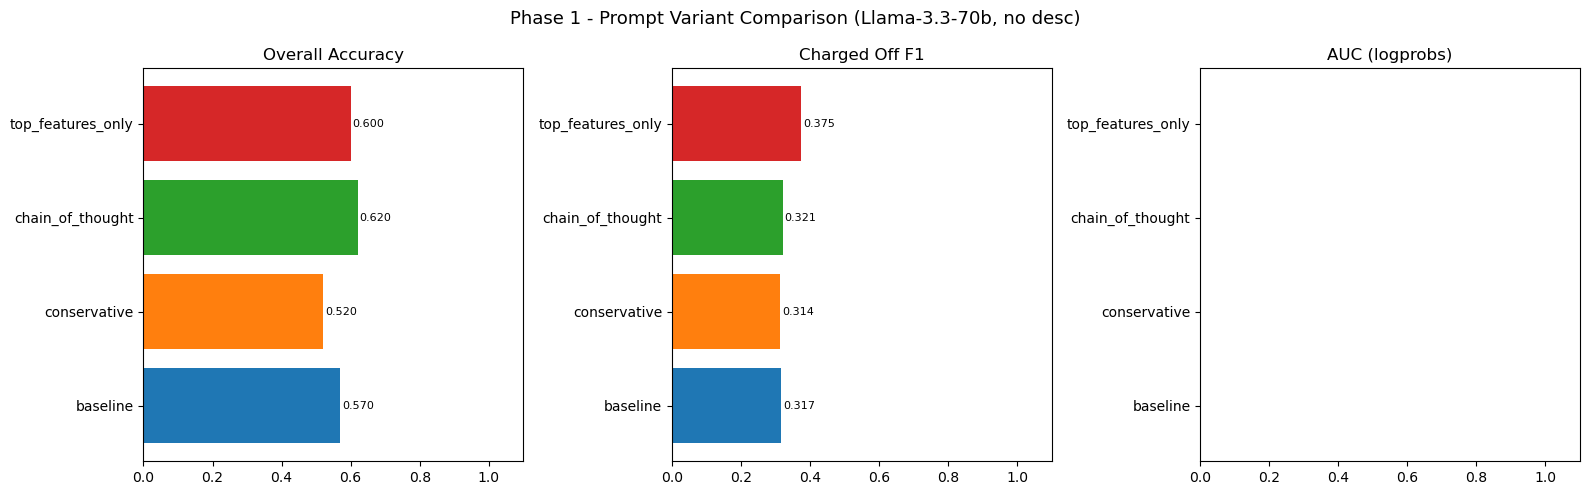

In [6]:
plot_df = phase1_summary.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phase 1 - Prompt Variant Comparison (Llama-3.3-70b, no desc)', fontsize=13)
colors = plt.cm.tab10.colors

for ax, (metric, title) in zip(axes, [
    ('accuracy',       'Overall Accuracy'),
    ('f1_charged_off', 'Charged Off F1'),
    ('auc',            'AUC (logprobs)'),
]):
    vals = plot_df[metric].apply(
        lambda x: 0.0 if (x is None or (isinstance(x, float) and np.isnan(x))) else float(x)
    )
    bars = ax.barh(plot_df['variant'], vals, color=colors[:len(plot_df)])
    for bar, val in zip(bars, plot_df[metric]):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlim(0, 1.1)

plt.tight_layout()
plt.show()

In [7]:
# Winner = highest Charged Off F1 (the metric that matters most for credit risk)
winner_name = max(
    phase1_results,
    key=lambda name: phase1_results[name]["metrics"]["f1_charged_off"] or 0
)
winner_variant = next(v for v in PROMPT_VARIANTS if v["name"] == winner_name)

print(f"Winner: [{winner_name}]")
print(f"Description: {winner_variant['description']}")
print(f"Charged Off F1: {phase1_results[winner_name]['metrics']['f1_charged_off']:.3f}")
print(f"Accuracy:       {phase1_results[winner_name]['metrics']['accuracy']:.3f}")
print(f"\nThis variant will be used for Phase 2 (consistency) and Phase 3 (robustness).")

Winner: [top_features_only]
Description: Only the 8 most important features by XGBoost importance are passed in
Charged Off F1: 0.375
Accuracy:       0.600

This variant will be used for Phase 2 (consistency) and Phase 3 (robustness).


---
## Phase 2 — Consistency
*Is the winning prompt stable, or does it flip predictions between runs?*

Same 100-loan sample, same winning prompt, run 3 times. We measure per-loan flip rate and metric variance across runs.

In [8]:
phase2_runs = []

for run_i in range(1, N_CONSISTENCY_RUNS + 1):
    print(f"\n{'='*60}\nConsistency run {run_i}/{N_CONSISTENCY_RUNS}\n{'='*60}")
    result = run_llm_experiment(
        llm_sample,
        api_provider=API_PROVIDER,
        model_name=MODEL_NAME,
        include_desc=False,
        label=f"{MODEL_LABEL} | {winner_name} | run{run_i}",
            with_logprobs=False,
            batch_size=0,
        system_prompt=winner_variant["system_prompt"],
        user_prompt_fn=winner_variant["user_prompt_fn"],
    )
    phase2_runs.append(result)

print(f"\nPhase 2 done: {N_CONSISTENCY_RUNS} runs completed")


Consistency run 1/3
[Llama-3.3-70b | top_features_only | run1 | no_desc] Batch call 1/1 (loans 0–99) ...
[Llama-3.3-70b | top_features_only | run1 | no_desc]  -> 100/100 parsed OK (230s elapsed)
[Llama-3.3-70b | top_features_only | run1 | no_desc] COMPLETE — 1 batch calls, 100/100 predictions parsed, 230s total

Llama-3.3-70b | top_features_only | run1 (no_desc) Results (100 samples)
Accuracy: 60.0%
AUC:      n/a  (only 0 rows had usable probabilities)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.23      0.73      0.35        15
  Fully Paid       0.92      0.58      0.71        85

    accuracy                           0.60       100
   macro avg       0.58      0.65      0.53       100
weighted avg       0.82      0.60      0.66       100

Confusion Matrix:
[[11  4]
 [36 49]]

Consistency run 2/3
[Llama-3.3-70b | top_features_only | run2 | no_desc] Batch call 1/1 (loans 0–99) ...
[Llama-3.3-70b | top_features_only | run2 | no_d

In [9]:
# Per-run metrics
p2_metrics = pd.DataFrame([
    {"run": i + 1, **r["metrics"]}
    for i, r in enumerate(phase2_runs)
]).set_index("run")

print("Per-run metrics:")
print(p2_metrics[["accuracy", "auc", "f1_charged_off"]].to_string(float_format="{:.3f}".format))

print(f"\nMean accuracy:        {p2_metrics['accuracy'].mean():.3f}  (std {p2_metrics['accuracy'].std():.3f})")
print(f"Mean Charged Off F1:  {p2_metrics['f1_charged_off'].mean():.3f}  (std {p2_metrics['f1_charged_off'].std():.3f})")
auc_vals = p2_metrics['auc'].dropna()
if len(auc_vals):
    print(f"Mean AUC:             {auc_vals.mean():.3f}  (std {auc_vals.std():.3f})")

# Per-loan stability: fraction of loans where ALL runs agree
all_preds = np.array([r["predictions"] for r in phase2_runs])
per_loan_stable = np.apply_along_axis(lambda col: len(set(col)) == 1, 0, all_preds)
print(f"\nPer-loan stability (all {N_CONSISTENCY_RUNS} runs agree): "
      f"{per_loan_stable.sum()}/100 ({per_loan_stable.mean()*100:.1f}%)")

# Which loans flipped?
flip_indices = np.where(~per_loan_stable)[0]
if len(flip_indices):
    print(f"Loans that flipped at least once: indices {list(flip_indices)}")
    flip_df = pd.DataFrame({
        "loan_index": flip_indices,
        "actual": y_true[flip_indices],
        **{f"run{i+1}": all_preds[i][flip_indices] for i in range(N_CONSISTENCY_RUNS)},
    })
    print(flip_df.to_string(index=False))
else:
    print("No loans flipped across runs — fully stable.")

Per-run metrics:
     accuracy   auc  f1_charged_off
run                                
1       0.600  None           0.355
2       0.590  None           0.369
3       0.570  None           0.358

Mean accuracy:        0.587  (std 0.015)
Mean Charged Off F1:  0.361  (std 0.008)

Per-loan stability (all 3 runs agree): 95/100 (95.0%)
Loans that flipped at least once: indices [np.int64(28), np.int64(37), np.int64(50), np.int64(64), np.int64(92)]
 loan_index  actual  run1  run2  run3
         28       1     1     1     0
         37       1     1     0     0
         50       1     1     0     0
         64       1     1     1     0
         92       0     1     0     0


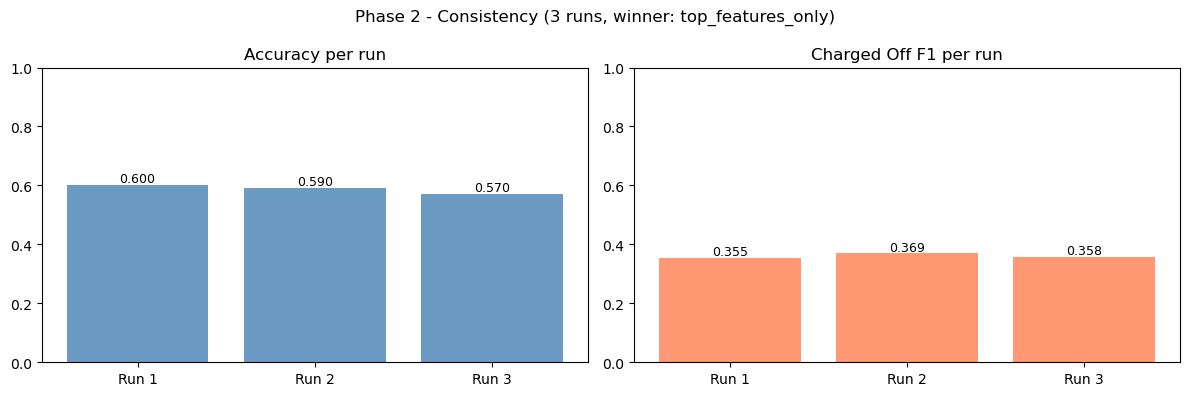

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Phase 2 - Consistency ({N_CONSISTENCY_RUNS} runs, winner: {winner_name})', fontsize=12)

runs = [f'Run {i}' for i in p2_metrics.index]

axes[0].bar(runs, p2_metrics['accuracy'], color='steelblue', alpha=0.8)
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy per run')
for i, v in enumerate(p2_metrics['accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(runs, p2_metrics['f1_charged_off'], color='coral', alpha=0.8)
axes[1].set_ylim(0, 1)
axes[1].set_title('Charged Off F1 per run')
for i, v in enumerate(p2_metrics['f1_charged_off']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


---
## Phase 3 — Robustness
*Does the winning prompt generalise to new, unseen loans?*

A fresh 100-loan batch is sampled from the held-out test set (excluding loans already in the evaluation sample). The winning prompt is run once on this new batch.

In [11]:
import os as _os

from llm_utils import DATA_DIR as _DATA_DIR
_raw_csv = _os.path.join(_DATA_DIR, '..', 'raw', 'accepted_2007_to_2018Q4.csv.gz')
_presampled = _os.path.join(_DATA_DIR, '04c_new_batch_sample.csv')

if _os.path.exists(_raw_csv):
    print('Sampling new held-out batch from raw CSV...')
    new_batch = sample_new_batch(n=100, random_state=99)
else:
    print(f'Raw CSV not found - loading pre-sampled held-out batch from {_presampled}')
    new_batch = pd.read_csv(_presampled)

y_true_new = new_batch['loan_status'].values
print(f'New batch: {len(new_batch)} loans | '
      f'Fully Paid: {(y_true_new==1).sum()} | Charged Off: {(y_true_new==0).sum()}')


Raw CSV not found - loading pre-sampled held-out batch from C:\Users\Jad Zoghaib\OneDrive\Desktop\Sabadell_Capstone\data\processed\04c_new_batch_sample.csv
New batch: 100 loans | Fully Paid: 77 | Charged Off: 23


In [12]:
print(f"Running [{winner_name}] on new batch...")
phase3_result = run_llm_experiment(
    new_batch,
    api_provider=API_PROVIDER,
    model_name=MODEL_NAME,
    include_desc=False,
    label=f"{MODEL_LABEL} | {winner_name} | new batch",
            with_logprobs=False,
            batch_size=0,
    system_prompt=winner_variant["system_prompt"],
    user_prompt_fn=winner_variant["user_prompt_fn"],
)

Running [top_features_only] on new batch...
[Llama-3.3-70b | top_features_only | new batch | no_desc] Batch call 1/1 (loans 0–99) ...
[Llama-3.3-70b | top_features_only | new batch | no_desc]  -> 100/100 parsed OK (216s elapsed)
[Llama-3.3-70b | top_features_only | new batch | no_desc] COMPLETE — 1 batch calls, 100/100 predictions parsed, 216s total

Llama-3.3-70b | top_features_only | new batch (no_desc) Results (100 samples)
Accuracy: 65.0%
AUC:      n/a  (only 0 rows had usable probabilities)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.38      0.78      0.51        23
  Fully Paid       0.90      0.61      0.73        77

    accuracy                           0.65       100
   macro avg       0.64      0.70      0.62       100
weighted avg       0.78      0.65      0.68       100

Confusion Matrix:
[[18  5]
 [30 47]]


In [13]:
p1_winner_metrics = phase1_results[winner_name]['metrics']
p3_metrics = phase3_result['metrics']

robustness_df = pd.DataFrame([
    {'split': 'Original sample (Phase 1)', **p1_winner_metrics},
    {'split': 'New batch (Phase 3)',       **p3_metrics},
]).set_index('split')

display_cols = ['accuracy', 'auc', 'precision_charged_off', 'recall_charged_off', 'f1_charged_off']
print('Robustness comparison:')
print(robustness_df[display_cols].to_string(float_format='{:.3f}'.format))

acc_drop = p1_winner_metrics['accuracy'] - p3_metrics['accuracy']
f1_drop  = p1_winner_metrics['f1_charged_off'] - p3_metrics['f1_charged_off']
print(f'\nPerformance drop (original -> new batch):')
print(f'  Accuracy:        {acc_drop:+.3f}')
print(f'  Charged Off F1:  {f1_drop:+.3f}')


Robustness comparison:
                           accuracy   auc  precision_charged_off  recall_charged_off  f1_charged_off
split                                                                                               
Original sample (Phase 1)     0.600  None                  0.245               0.800           0.375
New batch (Phase 3)           0.650  None                  0.375               0.783           0.507

Performance drop (original -> new batch):
  Accuracy:        -0.050
  Charged Off F1:  -0.132


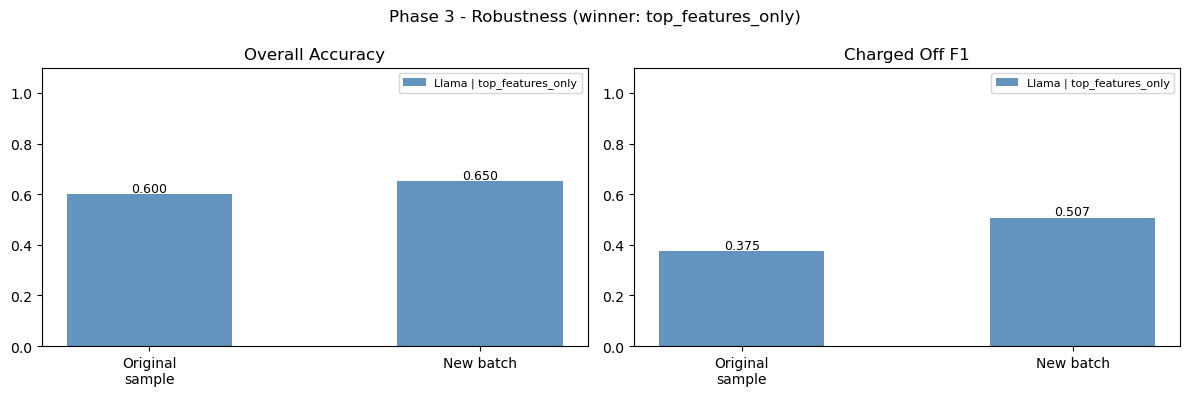

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Phase 3 - Robustness (winner: {winner_name})', fontsize=12)

groups = ['Original\nsample', 'New batch']
llm_acc = [p1_winner_metrics['accuracy'], p3_metrics['accuracy']]
llm_f1  = [p1_winner_metrics['f1_charged_off'], p3_metrics['f1_charged_off']]

x = np.arange(len(groups))
w = 0.5

for ax, (vals, title) in zip(axes, [
    (llm_acc, 'Overall Accuracy'),
    (llm_f1,  'Charged Off F1'),
]):
    bars = ax.bar(x, vals, w, label=f'Llama | {winner_name}', color='steelblue', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## Export Results

In [15]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Phase 1 - metrics
phase1_summary.to_csv(f'{RESULTS_DIR}/05_phase1_metrics.csv')

# Per-loan predictions + reasonings
pred_rows = []
for v in PROMPT_VARIANTS:
    name = v['name']
    if name not in phase1_results:
        continue
    result = phase1_results[name]
    for i, (pred, prob, reasoning) in enumerate(
        zip(result['predictions'], result['probabilities'], result['reasonings'])
    ):
        pred_rows.append({
            'phase': 1, 'variant': name, 'loan_index': i,
            'actual': int(y_true[i]), 'prediction': pred,
            'correct': int(pred == y_true[i]) if pred is not None else None,
            'prob_fully_paid': prob, 'reasoning': reasoning,
        })

# Phase 2 - per-run predictions
for run_i, result in enumerate(phase2_runs, 1):
    for i, (pred, prob, reasoning) in enumerate(
        zip(result['predictions'], result['probabilities'], result['reasonings'])
    ):
        pred_rows.append({
            'phase': 2, 'variant': f'{winner_name}_run{run_i}', 'loan_index': i,
            'actual': int(y_true[i]), 'prediction': pred,
            'correct': int(pred == y_true[i]) if pred is not None else None,
            'prob_fully_paid': prob, 'reasoning': reasoning,
        })

# Phase 3 - new batch predictions
for i, (pred, prob, reasoning) in enumerate(
    zip(phase3_result['predictions'], phase3_result['probabilities'], phase3_result['reasonings'])
):
    pred_rows.append({
        'phase': 3, 'variant': f'{winner_name}_new_batch', 'loan_index': i,
        'actual': int(y_true_new[i]), 'prediction': pred,
        'correct': int(pred == y_true_new[i]) if pred is not None else None,
        'prob_fully_paid': prob, 'reasoning': reasoning,
    })

pd.DataFrame(pred_rows).to_csv(f'{RESULTS_DIR}/05_predictions.csv', index=False)
p2_metrics.to_csv(f'{RESULTS_DIR}/05_phase2_consistency.csv')
robustness_df[display_cols].to_csv(f'{RESULTS_DIR}/05_phase3_robustness.csv')

with open(f'{RESULTS_DIR}/05_reasonings.jsonl', 'w', encoding='utf-8') as f:
    for row in pred_rows:
        f.write(json.dumps(row) + '\n')

print('Saved:')
print(f'  05_phase1_metrics.csv')
print(f'  05_predictions.csv ({len(pred_rows)} rows)')
print(f'  05_phase2_consistency.csv')
print(f'  05_phase3_robustness.csv')
print(f'  05_reasonings.jsonl  <- for promptfoo')
print(f'\nAll in: {RESULTS_DIR}')


Saved:
  05_phase1_metrics.csv
  05_predictions.csv (800 rows)
  05_phase2_consistency.csv
  05_phase3_robustness.csv
  05_reasonings.jsonl  <- for promptfoo

All in: C:\Users\Jad Zoghaib\OneDrive\Desktop\Sabadell_Capstone\data\results\llm
